In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle

from scipy.special import sici
from scipy.integrate import quad

In [48]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [293]:
from colossus.cosmology import cosmology
from colossus.halo import profile_nfw

cosmo = cosmology.setCosmology('planck15')
p_nfw = profile_nfw.NFWProfile(M = 1E15, c = 4.5
                               , z = 1.5, mdef = 'vir')

In [279]:
p_nfw.par

OrderedDict([('rhos', 8752678.421953915), ('rs', 217.25977181182637)])

In [280]:
physical_rho0 = p_nfw.par["rhos"]*(1e3)**3
print(physical_rho0)
physical_rs = p_nfw.par["rs"]/(1e3)

# convert to comoving
z = 1.5
rho0 = physical_rho0*(1+z)
rs = physical_rs*(1+z)
print(rho0)
print(rs)
rho0 = 1e7 * (1e3)**3
rs = 0.02
print(rho0)
print(rs)


8752678421953915.0
2.1881696054884788e+16
0.5431494295295659
1e+16
0.02


In [281]:
r = 10**np.arange(0,4,0.02)
rho_m = cosmo.rho_m(z)
rho_nfw = p_nfw.density(r)

In [282]:
Rmax = 250

en_mass = p_nfw.enclosedMass(Rmax)

In [283]:
print(en_mass/1e12)

260.28209528071955


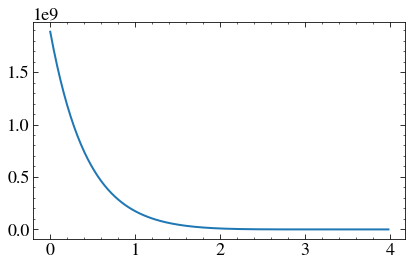

In [286]:
plt.plot(np.log10(r), rho_nfw)

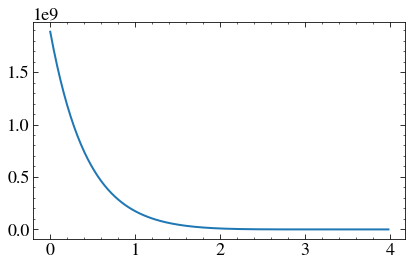

In [289]:
plt.plot(np.log10(r), rho_nfw)

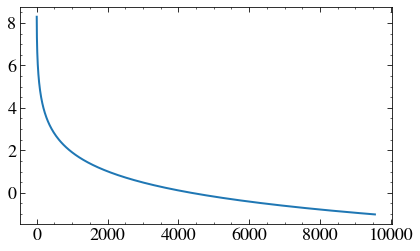

In [163]:
plt.plot(r, np.log10(rho_nfw))

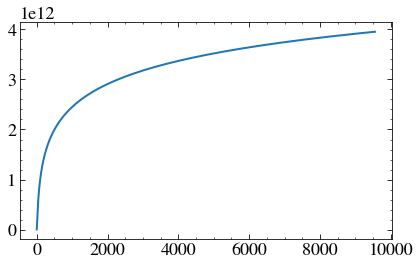

In [60]:
plt.plot(r, p_nfw.enclosedMass(r))

(0.0, 250.0)

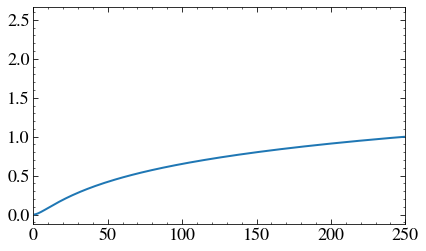

In [65]:
normed = p_nfw.cumulativePdf(r, Rmax=250)
plt.plot(r, normed)
plt.xlim(0,250)

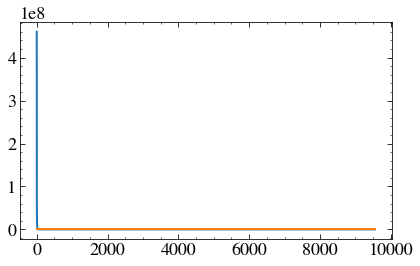

In [66]:

plt.plot(r, normed)

(0.0, 250.0)

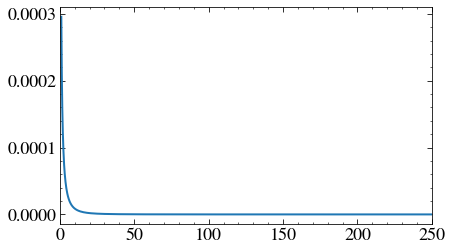

In [70]:
plt.plot(r,rho_nfw/en_mass)
plt.xlim(0,250)

In [296]:
import scipy.integrate as integrate
import scipy.special as special
r1 = np.arange(0.01,250,0.01)

result = integrate.trapezoid((4*np.pi*r1**2)*p_nfw.density(r1)/en_mass, r1)
print(result)

0.9999503733111608


In [81]:
vol = 4*np.pi*Rmax**3/3
rho_av = en_mass/vol


In [72]:
print(rho_av)

23782.92705198432


In [134]:
from scipy.special import sici

def nfw_fourier_analytical(k_values, rho_0, r_s):
    fourier_transform = np.zeros_like(k_values)
    
    for i, k in enumerate(k_values):
        kr_s = k * r_s
        if kr_s == 0:
            fourier_transform[i] = 4 * np.pi * rho_0 * r_s**3
        else:
            Si, Ci = sici(kr_s)
            term1 = np.sin(kr_s) * (Si - np.pi / 2)
            term2 = np.cos(kr_s) * (np.pi / 2 - Ci)
            fourier_transform[i] = 4 * np.pi * rho_0 * r_s**3 * (term1 + term2) / k**3
    
    return fourier_transform

In [131]:
logks = np.arange(-1.5,1.5,0.001)
ks = 10**logks
rho0 = physical_rho0*(1+z)
rs = physical_rs*(1+z)
u_ft = nfw_fourier_analytical(ks, rho0, rs)

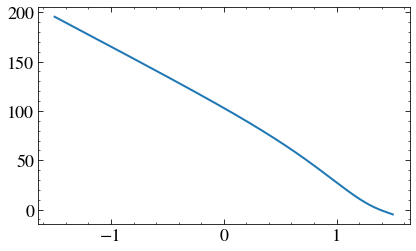

In [133]:
plt.plot(logks, u_ft)

In [ ]:
def pkpc_to_cmpch

In [294]:
def fourier_transform(k_values):
    ft_values = np.zeros_like(k_values)
    
    nbins = 10000
    r_vals_pkpc = np.linspace(1e-3, 100*(1+z), nbins)
    r_vals_cmpc = (1+z) * r_vals_pkpc/1e3
    
    rho_values_pkpc = p_nfw.density(r_vals_pkpc)
    
    rho_values_cmpc = rho_values_pkpc * (1+z)/1e3
    
    rho_values = rho_values_cmpc
    r_values = r_vals_cmpc
    dr = r_values[1] - r_values[0]
    for i, k in enumerate(k_values):
        integral = 4*np.pi*np.sum(r_values**2 * rho_values * np.sin(k * r_values) / (k * r_values) * dr)
        ft_values[i] = integral 
    
    return ft_values

In [266]:
Rmax = 100
en_mass = p_nfw.enclosedMass(Rmax/(1+z))

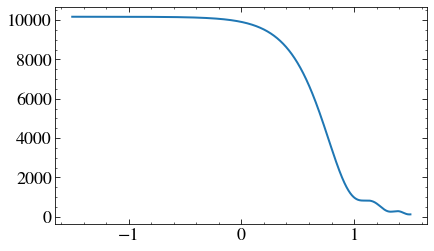

In [295]:
plt.plot(np.log10(ks), fourier_transform(ks))

In [267]:
print(en_mass/1e15)

0.015236035709791224


In [234]:
nbins = 10000

r_vals_pkpc = np.linspace(1e-4, 100*(1+z), nbins)
rho_values_pkpc = p_nfw.density(r_vals_pkpc)
    
rho_values_cmpc = rho_values_pkpc * (1+z)/1e3

r_vals_cmpc = (1+z) * r_vals_pkpc/1e3
rho_values = rho_values_cmpc

r_values = r_vals_cmpc
dr = r_values[1] - r_values[0]

np.sum(rho_values*dr)

122077.94545002408